# Minecraft Redstone NB Classifier: End-to-End Emulator

This notebook is a complete software emulation of the hardware system we are
building in Minecraft. It is organized in the same order as the hardware
pipeline so that each cell corresponds to one or more physical components.

**Sections**

0. Setup and dependencies
1. Data ingestion and token extraction
2. Multinomial Naive Bayes training
3. Quantization (4-bit and 8-bit comparison)
4. The sequential Shift-XOR word hash function (the SW/HW contract)
5. Gate-level hardware emulator (clock, latches, ROM, accumulators, argmax, PRNG, output)
6. Test suite

The emulator is deliberately low-level: registers are stored as lists of bits,
the ROM is modeled as 4-bit barrel atoms, the accumulator is a gate-level
ripple-carry adder, and so on. The goal is that if the emulator works, the
Redstone build should work for the same reasons (and fail for the same
reasons if it doesn't).

In [1]:
# ============================================================================
# Dependencies (all imports used in this notebook)
# ============================================================================

# --- Standard library ---
import os               # File path handling for dataset download.
import re               # Regex-based text cleaning (stripping non-alphabet chars).
import json             # Persisting quantized weights and metadata to disk.
import pickle           # Saving the trained sklearn model as a .pkl file.
import random           # Seeding for reproducibility in tests.
from collections import Counter  # Class balance inspection during data cleaning.
from dataclasses import dataclass, field  # Clean structuring of hardware registers.
from typing import List, Tuple, Dict, Optional  # Type hints for emulator clarity.

# --- Scientific stack ---
import numpy as np      # Array arithmetic, quantization math, weight tensors.
import pandas as pd     # Loading DailyDialog Parquet files.
from scipy.sparse import hstack, csr_matrix # Sparse matrix operations for hashing.

# --- Machine learning ---
from sklearn.feature_extraction.text import CountVectorizer  # Word-level token hashing vectorizer.
from sklearn.naive_bayes import MultinomialNB                # The classifier itself.
from sklearn.model_selection import train_test_split         # Validation split.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score  # Eval.
from sklearn.naive_bayes import ComplementNB                # Alternative NB variant.

# --- Plotting (used in test reports) ---
import matplotlib.pyplot as plt  # Quantization accuracy comparison, confusion matrices.

# --- Data management ---
from google.colab import drive  # Google Drive mounting for dataset access.

# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- File paths ---
DATA_DIR        = "data"
MODEL_PATH      = "nb_model.pkl"
WEIGHTS_8BIT    = "nb_weights_8bit.json"
WEIGHTS_4BIT    = "nb_weights_4bit.json"

os.makedirs(DATA_DIR, exist_ok=True)

print("All dependencies imported successfully.")

All dependencies imported successfully.


## 0.1 Downloading DailyDialog

We pull the Parquet mirror from Hugging Face. This file has columns
`dialog` (list of utterances), `act` (list of dialog act codes), and
`emotion` (list of emotion codes), one row per conversation.

The act codes are 1-indexed in the original dataset:
- 1 = inform
- 2 = question
- 3 = directive
- 4 = commissive

We will reindex these to 0–3 during cleaning to match standard sklearn
class index conventions and to fit in 2 bits for the hardware class index bus.

In [2]:
# ============================================================================
# Mount Google Drive and load the three manually downloaded DailyDialog files.
# Files expected at: My Drive/dailydialog/
#   - dialogues_train.txt
#   - dialogues_act_train.txt
#   - dialogues_emotion_train.txt
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

DIALOG_DIR = "/content/drive/MyDrive/dailydialog"

text_path    = os.path.join(DIALOG_DIR, "dialogues_train.txt")
act_path     = os.path.join(DIALOG_DIR, "dialogues_act_train.txt")
emotion_path = os.path.join(DIALOG_DIR, "dialogues_emotion_train.txt")

raw_texts, raw_labels, raw_emotions = [], [], []

with open(text_path,    encoding="utf-8") as ft, \
     open(act_path,     encoding="utf-8") as fa, \
     open(emotion_path, encoding="utf-8") as fe:

    for text_line, act_line, emo_line in zip(ft, fa, fe):
        # Each line is one dialogue.
        # Utterances are separated by __eou__ (end-of-utterance marker).
        # The last token after the final __eou__ is always empty — drop it.
        utterances = [u.strip() for u in text_line.strip().split("__eou__") if u.strip()]
        acts       = list(map(int, act_line.strip().split()))
        emotions   = list(map(int, emo_line.strip().split()))

        # Guard: skip malformed lines where counts don't align.
        if not (len(utterances) == len(acts) == len(emotions)):
            continue

        for utt, act, emo in zip(utterances, acts, emotions):
            raw_texts.append(utt)
            raw_labels.append(act - 1)    # 1-indexed -> 0-indexed (0=inform,1=question,2=directive,3=commissive)
            raw_emotions.append(emo)      # kept for reference, not used in training

print(f"Loaded {len(raw_texts)} utterances from {text_path.split('/')[-1]}")
print(f"Example utterance : {raw_texts[0][:80]}")
print(f"Example act label : {raw_labels[0]}  (0=inform 1=question 2=directive 3=commissive)")
print(f"Example emotion   : {raw_emotions[0]}")
print("\nRaw class distribution before cleaning:")
print(Counter(raw_labels))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 87170 utterances from dialogues_train.txt
Example utterance : Say , Jim , how about going for a few beers after dinner ?
Example act label : 2  (0=inform 1=question 2=directive 3=commissive)
Example emotion   : 0

Raw class distribution before cleaning:
Counter({0: 39873, 1: 24974, 2: 14242, 3: 8081})


## 1. Data Cleaning

The hardware constraints dictate every cleaning step:

| Hardware fact | Cleaning consequence |
|---|---|
| 5-bit keyboard, 27 chars used (a–z + space) | Strip everything except `[a-z ]` |
| All input is lowercase (no case bit) | `.lower()` everything |
| Tokens must exist to activate slots | Drop utterances shorter than 3 chars |
| 4 class indices fit in 2 bits | Reindex act labels from 1–4 to 0–3 |
| Naive Bayes is bag-of-features, no context | Flatten conversations to utterances; ignore turn order |


If a word token appears in training but cannot be typed at inference (e.g. `'s`,
`, `, `? `), the model wastes a slot on it. Every cleaning rule below is
about eliminating this mismatch.

In [3]:
# ============================================================================
# Flatten conversations to (text, label) pairs and apply hardware-aligned
# cleaning rules, while preserving the RAW text for the vectorizer.
# ============================================================================

def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z ]", "", s)
    s = re.sub(r" +", " ", s)
    return s.strip()

texts, labels, raws = [], [], []
for utterance, act in zip(raw_texts, raw_labels):
    cleaned = clean_text(utterance)
    if len(cleaned) >= 3:
        texts.append(cleaned)
        labels.append(act)
        raws.append(utterance) # Keep the raw text alongside!

print(f"Total utterances after cleaning: {len(texts)}")

counts = Counter(labels)
cap = min(counts.values())

balanced_texts, balanced_labels, raw_balanced_texts = [], [], []
class_seen = Counter()

# Shuffle deterministically before capping
combined = list(zip(texts, labels, raws))
random.Random(SEED).shuffle(combined)

for t, l, r in combined:
    if class_seen[l] >= cap:
        continue
    balanced_texts.append(t)
    balanced_labels.append(l)
    raw_balanced_texts.append(r) #Perfectly aligned raw texts
    class_seen[l] += 1

print(f"\nAfter rebalancing: {len(balanced_texts)} utterances")
print("Balanced class distribution:", Counter(balanced_labels))

Total utterances after cleaning: 86891

After rebalancing: 31904 utterances
Balanced class distribution: Counter({2: 7976, 1: 7976, 0: 7976, 3: 7976})


## 1.1 Bigram Extraction

We utilize a custom `HardwareHashVectorizer` that mimics our on-the-fly hardware tokenizer. It isolates full words and processes them through an **8-bit Shift-XOR** hash configuration (0–255), alongside 3 bypass slots for structural **punctuation markers**, yielding a hard locked 259-feature space.

In [4]:
# ============================================================================
# Instantiate the hardware-mapped hash vectorizer.
# ============================================================================

N_FEATURES = 256  # word-level slots; hardware ROM has 256 entries per class bank

# moved here from section 4
#------------------------------------------------------------------------------
def build_char_codes() -> Dict[str, int]:
    """Map a–z to 1–26, space to 27. Reclaim reserved slots for punctuation."""
    codes = {chr(ord('a') + i): i + 1 for i in range(26)}
    codes[' '] = 27
    codes['?'] = 28
    codes['!'] = 29
    return codes
CHAR_TO_CODE = build_char_codes()
CODE_TO_CHAR = {v: k for k, v in CHAR_TO_CODE.items()}
#------------------------------------------------------------------------------

class WordHash:
    """
    8-bit sequential Shift-XOR hash.
    Hardware equivalent: 8-bit shift register. On each clock, shift left by 1,
    wrap the MSB to LSB, and XOR with the incoming 5-bit character code.
    """
    @staticmethod
    def compute(word_chars: List[str]) -> int:
        h = 0
        for c in word_chars:
            code = CHAR_TO_CODE.get(c, 0)
            h = ((h << 1) | (h >> 7)) & 0xFF  # 8-bit circular left shift
            h = h ^ code
        return h

# ============================================================================
# Build the feature matrix. Maps RAW text directly to the 259 hardware slots.
# ============================================================================

class HardwareHashVectorizer:
    def fit_transform(self, raw_texts):
        return self.transform(raw_texts)

    def transform(self, raw_texts):
        rows, cols, data = [], [], []
        for row_idx, raw in enumerate(raw_texts):
            # 1. Extract punctuation from RAW text before it is destroyed
            if '?' in raw: rows.append(row_idx); cols.append(256); data.append(1)
            if '!' in raw: rows.append(row_idx); cols.append(257); data.append(1)

            cleaned = clean_text(raw)
            if len(cleaned.split()) > 8:
                rows.append(row_idx); cols.append(258); data.append(1)

            # 2. Sequential hashing for words
            for word in cleaned.split():
                slot = WordHash.compute(list(word))
                rows.append(row_idx); cols.append(slot); data.append(1)

        # Create matrix
        mat = csr_matrix((data, (rows, cols)), shape=(len(raw_texts), 259))

        # FIX 2: Binarize the matrix. An RS Latch saturates at 1.
        # By clipping >1 to 1, we force MultinomialNB to train exactly
        # how the hardware will behave at inference.
        mat.data = np.ones_like(mat.data)
        return mat

# Pass RAW uncleaned texts into the vectorizer so punctuation survives
vectorizer = HardwareHashVectorizer()
X_all = vectorizer.fit_transform(raw_balanced_texts)

vocab_bigrams = [f"slot_{i}" for i in range(259)]
print(f"Final feature matrix shape: {X_all.shape}")
print(f"  256 word slots + 3 punctuation slots = 259 total")

Final feature matrix shape: (31904, 259)
  256 word slots + 3 punctuation slots = 259 total


## 2. Training Multinomial Naive Bayes

We train `MultinomialNB` with Laplace smoothing (`alpha=1.0`) to prevent any
log-probability from being `-inf` (which would quantize badly). The model's
`feature_log_prob_` matrix is the main weight tensor we will quantize and
load into the Redstone ROMs.

We save the entire fitted sklearn object as a `.pkl` for completeness, then
also extract just the components we need for hardware (Section 3).

In [5]:
# ============================================================================
# Train Multinomial NB and persist the model.
# ============================================================================

X_train, X_val, y_train, y_val = train_test_split(
    raw_balanced_texts, # Use raw texts so validation tests see punctuation
    balanced_labels,
    test_size=0.1,
    stratify=balanced_labels,
    random_state=SEED,
)

# Keep MultinomialNB (not switching to Bernoulli)
clf = MultinomialNB(alpha=1.0)
X_train_vec = vectorizer.transform(X_train)
X_val_vec = vectorizer.transform(X_val)

clf.fit(X_train_vec, y_train)

y_pred_float = clf.predict(X_val_vec)
baseline_acc = accuracy_score(y_val, y_pred_float)

print(f"Float-precision validation accuracy: {baseline_acc:.4f}")
print("\nClassification report:")
print(classification_report(
    y_val, y_pred_float,
    target_names=["inform", "question", "directive", "commissive"]
))

# Save the full sklearn model for reproducibility.
with open(MODEL_PATH, "wb") as f:
    pickle.dump({"vectorizer": vectorizer, "clf": clf}, f)

print(f"\nModel saved to {MODEL_PATH}")

Float-precision validation accuracy: 0.6158

Classification report:
              precision    recall  f1-score   support

      inform       0.56      0.54      0.55       798
    question       0.76      0.84      0.80       797
   directive       0.56      0.52      0.54       798
  commissive       0.56      0.57      0.56       798

    accuracy                           0.62      3191
   macro avg       0.61      0.62      0.61      3191
weighted avg       0.61      0.62      0.61      3191


Model saved to nb_model.pkl


## 3. Quantization (4-bit vs 8-bit)

### What needs to be quantized (and what doesn't)
Here is the full mapping:

| sklearn attribute | Goes into ROM? | Why |
|---|---|---|
| `feature_log_prob_` (shape `[4, 259]`) | **YES — main weight ROM** | The dominant inference signal |
| `class_log_prior_` (shape `[4]`) | **YES — small prior ROM** | Added once at the start of each inference |
| `classes_` | No | Used to label outputs in SW; in HW the class index *is* the label |
| `class_count_`, `feature_count_` | No | Training-time intermediates, not used at inference |
| `n_features_in_`, `feature_names_in_` | Compile-time only | Determines ROM dimensions but isn't stored as data |
| `alpha`, `fit_prior`, `force_alpha`, `class_prior` | No | Training hyperparams |
| `HardwareHashVectorizer` math | **Indirectly** | Used to compute the 8-bit Shift-XOR hash map; the math is built into the physical Redstone layout. Hardware reads slots, not explicitly stored words. |

So **two separate ROMs** are needed:
1. **Weight ROM** — 4 banks (one per class), each with N_FEATURES 8-bit signed entries.
2. **Prior ROM** — 1 tiny bank with 4 entries of 8-bit signed values.

These map cleanly to two physically separate barrel ROM structures in the
Minecraft build. Storing them separately is mandatory because they have
different access patterns: the prior ROM is read 4 times during initialization,
the weight ROM is read 259 times per inference (one per slot).

### Why both 4-bit and 8-bit

Your hardware uses 4-bit barrels, but two stacked barrels naturally form an
8-bit value. The question is whether the accuracy at 4-bit is acceptable —
if yes, the ROM is half the size. The test suite below compares both.

### The quantization scheme

Both `feature_log_prob_` and `class_log_prior_` are negative (log-probabilities
of probabilities in [0, 1]). We map `[min_value, 0]` symmetrically into the
signed integer range using the absolute minimum as the scale factor. This
preserves relative magnitudes and signs.

In [9]:
# ============================================================================
# Quantization with three fixes:
# 1. Shift weights to positive range before quantizing (hardware-friendly)
# 2. Skip prior ROM (all priors equal after balancing; adds same constant
#    to all classes so it does not affect argmax — omit it)
# 3. Verify accumulator width is sufficient for the chosen bit depth
# ============================================================================

def quantize_weights(log_prob: np.ndarray, bits: int) -> Tuple[np.ndarray, float, float]:
    """
    Shift-then-scale quantization for all-negative log-probability weights.

    Step 1: Shift the entire matrix so the maximum value becomes 0.
            This converts all-negative values to all-non-negative values
            (range [original_min - original_max, 0] becomes [shifted_min, 0]).
            The shift is identical for every class so it cancels in argmax —
            same as the prior cancellation above. No information is lost.

    Step 2: Scale [shifted_min, 0] to [-(2^(bits-1) - 1), 0].

    Returns (quantized_array, shift, scale).
    The shift and scale are saved in the JSON so the emulator can verify
    dequantization if needed, but hardware never uses them.
    """
    shift = float(log_prob.max())               # e.g. -0.693 (the least-negative value)
    shifted = log_prob - shift                   # now range is [some_negative, 0]
    qmax = (1 << (bits - 1)) - 1                # 127 for 8-bit, 7 for 4-bit
    scale = float(-shifted.min() / qmax)        # positive scale factor
    q = np.round(shifted / scale).astype(np.int32)
    q = np.clip(q, -qmax, qmax)
    return q, shift, scale


def check_accumulator_width(q_weights: np.ndarray, bits: int, acc_bits: int = 12) -> None:
    """
    Verify that the worst-case accumulated score fits in acc_bits signed integer.
    Worst case: all features present, all weights as negative as possible.
    """
    n_features = q_weights.shape[1]
    worst = int(q_weights.min()) * n_features
    limit = -(1 << (acc_bits - 1))
    print(f"  Accumulator check ({bits}-bit weights, {acc_bits}-bit accumulator):")
    print(f"    Worst-case sum = {worst}")
    print(f"    {acc_bits}-bit signed limit = {limit}")
    if worst < limit:
        needed = int(np.ceil(np.log2(abs(worst) + 1))) + 1
        print(f"    WARNING: OVERFLOW. Need at least {needed}-bit accumulator.")
    else:
        print(f"    OK: fits within {acc_bits}-bit accumulator.")


q_weights_8, shift_8, w_scale_8 = quantize_weights(clf.feature_log_prob_, bits=8)
q_weights_4, shift_4, w_scale_4 = quantize_weights(clf.feature_log_prob_, bits=4)

print("=" * 60)
print("8-bit quantization summary")
print("=" * 60)
print(f"  weights: shape {q_weights_8.shape}, range [{q_weights_8.min()}, {q_weights_8.max()}]")
print(f"  shift={shift_8:.6f}, scale={w_scale_8:.6f}")
check_accumulator_width(q_weights_8, bits=8, acc_bits=16)

print()
print("=" * 60)
print("4-bit quantization summary")
print("=" * 60)
print(f"  weights: shape {q_weights_4.shape}, range [{q_weights_4.min()}, {q_weights_4.max()}]")
print(f"  shift={shift_4:.6f}, scale={w_scale_4:.6f}")
check_accumulator_width(q_weights_4, bits=4, acc_bits=12)

print()
print("Prior ROM: OMITTED (all priors equal after class balancing)")
print("Hardware accumulators initialize to 0 instead of loading priors.")

# Save weights. Note: prior_rom key is kept in JSON for documentation
# but marked as omitted so downstream code knows not to use it.
def save_weights(path, q_w, shift, scale, bits):
    payload = {
        "bits": bits,
        "n_features": int(q_w.shape[1]),
        "n_classes":  int(q_w.shape[0]),
        "weight_rom": {
            "data":  q_w.tolist(),
            "shift": shift,
            "scale": scale,
        },
        "prior_rom": {
            "omitted": True,
            "reason": "All class priors equal after balancing; constant cancels in argmax.",
        },
        "vocab": vocab_bigrams,
    }
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

save_weights(WEIGHTS_8BIT, q_weights_8, shift_8, w_scale_8, 8)
save_weights(WEIGHTS_4BIT, q_weights_4, shift_4, w_scale_4, 4)
print(f"\nWrote {WEIGHTS_8BIT} and {WEIGHTS_4BIT}")

8-bit quantization summary
  weights: shape (4, 259), range [-127, 0]
  shift=-2.300494, scale=0.048977
  Accumulator check (8-bit weights, 16-bit accumulator):
    Worst-case sum = -32893
    16-bit signed limit = -32768

4-bit quantization summary
  weights: shape (4, 259), range [-7, 0]
  shift=-2.300494, scale=0.888575
  Accumulator check (4-bit weights, 12-bit accumulator):
    Worst-case sum = -1813
    12-bit signed limit = -2048
    OK: fits within 12-bit accumulator.

Prior ROM: OMITTED (all priors equal after class balancing)
Hardware accumulators initialize to 0 instead of loading priors.

Wrote nb_weights_8bit.json and nb_weights_4bit.json


In [10]:
# Diagnostic: check the float priors before quantization
print("Float class priors (should be 4 different values):")
print(clf.class_log_prior_)
print("\nMin, max, mean:")
print(f"  min={clf.class_log_prior_.min():.6f}")
print(f"  max={clf.class_log_prior_.max():.6f}")
print(f"  mean={clf.class_log_prior_.mean():.6f}")

Float class priors (should be 4 different values):
[-1.38632919 -1.38618988 -1.38632919 -1.38632919]

Min, max, mean:
  min=-1.386329
  max=-1.386190
  mean=-1.386294


## 4. The sequential Shift-XOR word hash function (the SW/HW contract)

This is the **single most important contract between SW and HW**. The same
hash function must operate at both training-data preparation time and at
inference time inside the Redstone build. If they disagree by even one bit
on a single slot, the model is silently wrong everywhere.

### Encoding (5-bit character codes)

| Char | Code (decimal) | Code (5 bits) |
|---|---|---|
| `a` | 1  | `00001` |
| `b` | 2  | `00010` |
| …   | …  | … |
| `z` | 26 | `11010` |
| `' '` (space) | 27 | `11011` |
| `?` | 28 | `11100` |
| `!` | 29 | `11101` |

### The Hash

Instead of storing a vocabulary table, full words are accumulated and hashed into an 8-bit address space (0-255).
1. The 8-bit register initializes to 0.
2. For each character in a word, the register circular-shifts left by 1 bit.
3. The incoming 5-bit character code is XORed into the register.
4. When a space (`27`) is hit, the 8-bit value is latched via an 8-to-256 decoder.

Punctuation markers (`?`, `!`, and a `>8 words` counter) bypass this hash entirely and are hardwired directly to slots 256, 257, and 258.

### Software side (this notebook)

We compute the slot for every word in the training set using `HardwareHashVectorizer` and map it into a 259-feature sparse matrix. **This is the canonical software model** of what the hardware does.

### Hardware side (Minecraft)

The hardware never sees the explicit word strings. The keyboard outputs 5-bit character codes directly into a variable-length buffer. Upon hitting a space, the 8-bit shift register computes the slot index and fires the correct set line on the latch array. The model trained in this notebook has already learned the slot-level statistics, so as long as the encoding and hash function match, the predictions agree.

In [11]:
# ============================================================================
# Character encoding and the XOR hash. Used everywhere downstream.
# ============================================================================


# removed xor_hash, hash_string_to_slots, and bigrams_to_slot_map




# Compute slot utilization across the entire dataset to check hash distribution
slot_counts = np.array(X_all.sum(axis=0)).flatten()
active_slots = np.sum(slot_counts > 0)

print("Slot utilization for the 259 hardware latches:")
print(f"  {active_slots} distinct slots used out of 259.")
print(f"  {259 - active_slots} slots are completely empty.")

# Check for severe collisions (slots triggered unusually often)
top_slots = np.argsort(slot_counts)[-5:][::-1]
print("\nTop 5 most triggered slots (0-255 are words, 256-258 are punctuation):")
for s in top_slots:
    print(f"  Slot {s:3d}: triggered {slot_counts[s]:.0f} times")

Slot utilization for the 259 hardware latches:
  259 distinct slots used out of 259.
  0 slots are completely empty.

Top 5 most triggered slots (0-255 are words, 256-258 are punctuation):
  Slot 258: triggered 16557 times
  Slot 111: triggered 13090 times
  Slot   1: triggered 12950 times
  Slot 256: triggered 11349 times
  Slot   9: triggered 10538 times


## 5. Hardware Emulator

This section emulates every stage of the Minecraft build at the lowest
practical level in Python. Each component is a class. Every register is a
list of bit integers (0 or 1). Every "wire" between components is an explicit
signal passed by method call. There is no hidden state, no Python magic;
what's here is what gets built in Redstone.

### Component-to-class mapping

| Hardware stage | Emulator class | Key methods |
|---|---|---|
| 5-bit DFF | `DFlipFlop5` | `tick(data, clk)` |
| Variable keyboard buffer | `VariableKeyboardBuffer` | `keypress(char)` |
| Shift-XOR Register | `WordHash` | `compute(word_chars) → 8-bit slot index` |
| 8-to-256 decoder | `OneHotDecoder8` | `decode(addr_bits) → 256 one-hot bits` |
| Feature latch array | `LatchArray` | `set(slot)`, `reset()`, `read()` |
| 4-bit barrel | `Barrel4` | `read()` (atomic ROM unit) |
| Weight ROM bank | `WeightROM` | `read(addr, class_idx) → signed 8-bit` |
| Prior ROM | `PriorROM` | `read(class_idx) → signed 8-bit` |
| AND-gate weight gate | `AndGate8` | `gate(weight_bits, enable_bit)` |
| 17-bit ripple-carry adder | `Adder17` | `add(a_bits, b_bits) → 17-bit sum` |
| Class accumulator | `Accumulator17` | `load(value)`, `accumulate(weight, enable)` |
| Comparator | `Comparator17` | `greater_eq(a_bits, b_bits) → winner` |
| Argmax tree | `ArgmaxTree` | `argmax(scores) → 2-bit class idx` |
| 4-bit LFSR | `LFSR4` | `tick()`, `read()` |
| Output ROM | `OutputROM` | `read(class_idx, variant) → response str` |
| Lamp bank | `LampBank` | `display(char_code)` |
| Top-level system | `MinecraftNBSystem` | `infer(text)` |

### Bit conventions

Throughout the emulator, all multi-bit values are represented as **lists of
bits, LSB first**. So the integer 5 (`0b00101`) as a 5-bit value is `[1, 0, 1, 0, 0]`.
This matches the natural Redstone wire ordering (the first wire on the bus is
bit 0). Two's complement is used for all signed values.

In [12]:
# ============================================================================
# Bit-level utilities. Everything in the emulator goes through these.
# ============================================================================

def int_to_bits(value: int, width: int) -> List[int]:
    """
    Convert an integer to a list of bits, LSB first.
    For negative values, encodes as two's complement in `width` bits.
    """
    if value < 0:
        value = (1 << width) + value         # two's complement
    return [(value >> i) & 1 for i in range(width)]


def bits_to_int(bits: List[int], signed: bool = False) -> int:
    """Inverse of int_to_bits. If signed, interpret MSB as sign bit."""
    value = 0
    for i, b in enumerate(bits):
        value |= (b & 1) << i
    if signed and bits and bits[-1] == 1:
        value -= (1 << len(bits))
    return value


def sign_extend(bits: List[int], new_width: int) -> List[int]:
    """
    Extend a two's complement value to a wider bit width by replicating
    the MSB. This is exactly what happens physically in Redstone: the
    sign bit wire is routed to all upper-bit inputs of the wider adder.
    """
    if new_width <= len(bits):
        return bits[:new_width]
    sign_bit = bits[-1] if bits else 0
    return bits + [sign_bit] * (new_width - len(bits))


# --- Gate primitives (every component composes these) ---
def gate_and(a: int, b: int) -> int:  return a & b
def gate_or (a: int, b: int) -> int:  return a | b
def gate_not(a: int)         -> int:  return 1 - a
def gate_xor(a: int, b: int) -> int:  return a ^ b


def full_adder(a: int, b: int, cin: int) -> Tuple[int, int]:
    """
    Standard full adder: sum = a XOR b XOR cin, carry = majority(a, b, cin).
    Returns (sum_bit, carry_out). This is the building block of every
    multi-bit adder in the system.
    """
    s = gate_xor(gate_xor(a, b), cin)
    c = gate_or(gate_or(gate_and(a, b), gate_and(a, cin)), gate_and(b, cin))
    return s, c

In [13]:
# ============================================================================
# Storage primitives: DFFs and RS latches.
# ============================================================================

@dataclass
class DFlipFlop5:
    """
    5-bit D flip-flop. Captures `data` on a rising clock edge.
    Two of these stacked = the keyboard buffer (Stage 0).
    """
    q: List[int] = field(default_factory=lambda: [0] * 5)
    _prev_clk: int = 0

    def tick(self, data: List[int], clk: int) -> List[int]:
        if clk == 1 and self._prev_clk == 0:   # rising edge
            self.q = list(data)
        self._prev_clk = clk
        return list(self.q)


@dataclass
class RSLatch:
    """
    Set–reset latch built from two cross-coupled NOR gates.
    259 of these form the feature presence latch array (Stage 2).
    """
    q: int = 0

    def update(self, s: int, r: int) -> int:
        # NOR(NOR(R, Q'), S) — settles to expected behavior:
        # S=1,R=0 -> Q=1 ; S=0,R=1 -> Q=0 ; S=0,R=0 -> hold.
        if r == 1:
            self.q = 0
        elif s == 1:
            self.q = 1
        return self.q


class LatchArray:
    """
    259 RS latches representing the feature presence vector.
    The set inputs are driven by a one-hot decoder (Cell 18).
    """
    def __init__(self, n: int = 259):
        self.latches = [RSLatch() for _ in range(n)]
        self.n = n

    def set_slot(self, slot: int) -> None:
        """Pulse the set line for one latch. Other set lines stay 0."""
        for i, latch in enumerate(self.latches):
            s = 1 if i == slot else 0
            latch.update(s=s, r=0)

    def reset_all(self) -> None:
        """Global reset wire: all R inputs high simultaneously."""
        for latch in self.latches:
            latch.update(s=0, r=1)

    def read(self) -> List[int]:
        return [latch.q for latch in self.latches]

In [14]:
# ============================================================================
# Stage 0: Keyboard buffer; Stage 1: XOR hash; Stage 2 decoder.
# ============================================================================

class VariableKeyboardBuffer:
    """
    Accumulates character codes until a space delimiter is hit, then triggers a hash.
    Tracks total word count to trigger the 'is_long' punctuation feature.
    """
    def __init__(self):
        self.current_word = []
        self.word_count = 0
        self.punct_flags = [0, 0, 0] # [?, !, >8 words]

    def keypress(self, char: str) -> Tuple[Optional[int], List[int]]:
        """Returns (hashed_slot, active_punct_flags) on word completion."""
        code = CHAR_TO_CODE.get(char, 0)

        if code == 28: self.punct_flags[0] = 1 # ?
        elif code == 29: self.punct_flags[1] = 1 # !

        if code == 27 or not char.isalpha(): # Space or flush
            if not self.current_word: return None, self.punct_flags

            slot = WordHash.compute(self.current_word)
            self.word_count += 1
            self.current_word = []

            if self.word_count > 8:
                self.punct_flags[2] = 1

            return slot, self.punct_flags

        self.current_word.append(char)
        return None, self.punct_flags



class OneHotDecoder8:
    @staticmethod
    def decode(addr_bits: List[int]) -> List[int]:
        addr = bits_to_int(addr_bits, signed=False)
        out = [0] * 256
        if 0 <= addr < 256:
            out[addr] = 1
        return out

In [15]:
# ============================================================================
# The barrel ROM. This is the storage primitive of the Minecraft build:
# each "barrel" stores 4 bits of one weight (and two barrels stacked store
# one 8-bit signed weight).
# ============================================================================

@dataclass
class Barrel4:
    """
    Atomic 4-bit storage cell. In Minecraft, this is a barrel with item
    counts encoding 4 bits via signal strength (0-15 = 16 levels).
    """
    nibble: int = 0   # 0..15

    def read(self) -> List[int]:
        return int_to_bits(self.nibble & 0xF, 4)


class WeightROM:
    """
    Weight ROM as 4 banks of N 8-bit signed weights, each value stored as
    two stacked 4-bit barrels (LSB barrel + MSB barrel).

    Hardware view: addr_bits drive a 9-bit address line shared by all 4
    banks. The selected row's (low_barrel, high_barrel) are read in
    parallel and concatenated into an 8-bit signed value.

    Storage layout: barrels[class_idx][slot_idx] -> (low_nibble, high_nibble)
    """
    def __init__(self, q_weights: np.ndarray):
        """q_weights: shape [n_classes, n_features], signed integers in 8-bit range."""
        n_classes, n_features = q_weights.shape
        self.n_classes = n_classes
        self.n_features = n_features
        self.barrels: List[List[Tuple[Barrel4, Barrel4]]] = []

        for c in range(n_classes):
            row = []
            for f in range(n_features):
                w = int(q_weights[c, f])
                if w < 0:
                    w = (1 << 8) + w        # two's complement in 8 bits
                low  = Barrel4(nibble= w        & 0xF)
                high = Barrel4(nibble=(w >> 4)  & 0xF)
                row.append((low, high))
            self.barrels.append(row)

    def read(self, addr_bits: List[int], class_idx: int) -> List[int]:
        """
        Hardware-faithful read: address drives the bank, two barrels of the
        selected row produce 4 + 4 = 8 bits in parallel.
        Returns 8 bits LSB-first (two's complement signed).
        """
        addr = bits_to_int(addr_bits, signed=False)
        low_b, high_b = self.barrels[class_idx][addr]
        return low_b.read() + high_b.read()


class PriorROM:
    """
    Tiny prior ROM: one 8-bit signed value per class.
    Read once per inference (during accumulator initialization).
    """
    def __init__(self, q_priors: np.ndarray):
        self.barrels: List[Tuple[Barrel4, Barrel4]] = []
        for p in q_priors:
            v = int(p)
            if v < 0:
                v = (1 << 8) + v
            self.barrels.append((Barrel4(nibble=v & 0xF),
                                 Barrel4(nibble=(v >> 4) & 0xF)))

    def read(self, class_idx: int) -> List[int]:
        low_b, high_b = self.barrels[class_idx]
        return low_b.read() + high_b.read()

In [16]:
# ============================================================================
# Ripple-carry adder and accumulator. These are the most timing-critical
# pieces of the Redstone build, so the emulator builds them gate by gate.
# ============================================================================

class Adder17:
    @staticmethod
    def add(a_bits: List[int], b_bits: List[int], cin: int = 0) -> Tuple[List[int], int]:
        assert len(a_bits) == 17 and len(b_bits) == 17
        sum_bits = []
        carry = cin
        for i in range(17):
            s, c = full_adder(a_bits[i], b_bits[i], carry)
            sum_bits.append(s)
            carry = c
        return sum_bits, carry

class Accumulator17:
    def __init__(self):
        self.value_bits = [0] * 17

    def load(self, init_bits_8: List[int]) -> None:
        self.value_bits = sign_extend(init_bits_8, 17)

    def accumulate(self, gated_weight_bits_8: List[int]) -> None:
        ext = sign_extend(gated_weight_bits_8, 17)
        self.value_bits, _ = Adder17.add(self.value_bits, ext)

    def read_signed(self) -> int:
        return bits_to_int(self.value_bits, signed=True)


class AndGate8:
    """
    8-bit conditional pass-through. If enable=1, output equals input; else 0.
    Implemented as 8 parallel AND gates sharing the enable wire.
    This is the heart of the Bernoulli inference simplification.
    """
    @staticmethod
    def gate(weight_bits: List[int], enable: int) -> List[int]:
        return [gate_and(w, enable) for w in weight_bits]


In [17]:
# ============================================================================
# Comparator and argmax tree (Stage 4).
# ============================================================================

class Comparator17:
    @staticmethod
    def greater_eq(a_bits: List[int], b_bits: List[int]) -> int:
        b_inv = [gate_not(x) for x in b_bits]
        diff, _ = Adder17.add(a_bits, b_inv, cin=1)
        sign = diff[-1]
        return gate_not(sign)

class ArgmaxTree:
    @staticmethod
    def argmax(scores: List[List[int]]) -> List[int]:
        assert len(scores) == 4
        win01 = Comparator17.greater_eq(scores[0], scores[1])
        win23 = Comparator17.greater_eq(scores[2], scores[3])

        finalist_a = scores[0] if win01 else scores[1]
        finalist_b = scores[2] if win23 else scores[3]
        idx_a = [0, 0] if win01 else [1, 0]
        idx_b = [0, 1] if win23 else [1, 1]

        win_final = Comparator17.greater_eq(finalist_a, finalist_b)
        return idx_a if win_final else idx_b

In [18]:
# ============================================================================
# Stage 5: PRNG (LFSR), output ROM, lamp display.
# ============================================================================

class LFSR4:
    """
    4-bit linear feedback shift register with polynomial x^4 + x^3 + 1.
    Cycles through 15 non-zero states before repeating.
    Seeded to a non-zero value (all-zeros is a fixed point and produces 0 forever).
    """
    def __init__(self, seed: int = 0b1011):
        assert seed != 0
        self.state = [(seed >> i) & 1 for i in range(4)]

    def tick(self) -> None:
        feedback = gate_xor(self.state[3], self.state[2])
        # Shift toward MSB; new bit enters at LSB.
        self.state = [feedback] + self.state[:3]

    def read_low2(self) -> int:
        """Use the low 2 bits to select a variant in [0, 1, 2, 3]."""
        return self.state[0] | (self.state[1] << 1)


# Pre-stored output strings, indexed [class][variant].
# Encoded directly as character codes that the lamp bank can render.
RESPONSE_STRINGS = [
    ["noted",          "i see",          "understood"   ],   # inform
    ["good question",  "interesting",    "tell me more" ],   # question
    ["i will try",     "certainly",      "on it"        ],   # directive
    ["agreed",         "sounds good",    "lets do it"   ],   # commissive
]


class OutputROM:
    """
    16-entry ROM addressed by {class[1:0], variant[1:0]}. Each entry stores
    a fixed-length sequence of 5-bit character codes (10-char max, padded
    with space code 27). Unused class/variant combinations are blank.
    """
    MAX_LEN = 13

    def __init__(self):
        self.entries: Dict[Tuple[int, int], List[int]] = {}
        for c in range(4):
            for v in range(3):
                text = RESPONSE_STRINGS[c][v]
                # Pad with space to fixed length.
                padded = text + ' ' * (self.MAX_LEN - len(text))
                codes = [CHAR_TO_CODE.get(ch, 27) for ch in padded]
                self.entries[(c, v)] = codes
            # Variant 3 (unused): mirror variant 0 so the LFSR's 4th state
            # produces a valid response.
            self.entries[(c, 3)] = self.entries[(c, 0)]

    def read(self, class_idx: int, variant: int) -> List[int]:
        return list(self.entries[(class_idx, variant)])


class LampBank:
    """
    5-lamp display. Receives a 5-bit char code per output clock and stores
    the most recent character for inspection. In the real build this drives
    a row of 5 redstone lamps; we just record the string.
    """
    def __init__(self):
        self.buffer: List[str] = []

    def display(self, char_code: int) -> None:
        self.buffer.append(CODE_TO_CHAR.get(char_code, '?'))

    def clear(self) -> None:
        self.buffer = []

    def text(self) -> str:
        return ''.join(self.buffer).rstrip()

In [19]:
# ============================================================================
# Top-level system. Wires every stage together exactly as the Minecraft
# build does, and exposes a single `infer(text)` method.
# ============================================================================

class MinecraftNBSystem:
    """
    Complete hardware emulation. The order of operations in `infer()` mirrors
    the order in which clock edges fire in the real build.
    """
    def __init__(self, weights_path: str):
        with open(weights_path) as f:
            data = json.load(f)
        q_weights = np.array(data["weight_rom"]["data"], dtype=np.int32)

        # Handle the omitted Prior ROM by defaulting to 0
        if data.get("prior_rom", {}).get("omitted", False):
            q_priors = np.zeros(data["n_classes"], dtype=np.int32)
        else:
            q_priors  = np.array(data["prior_rom"]["data"],  dtype=np.int32)

        self.bits = data["bits"]
        self.n_classes  = data["n_classes"]
        self.n_features = data["n_features"]

        # Allocate all components.
        self.kbd          = VariableKeyboardBuffer()
        self.hash_unit    = WordHash()
        self.decoder      = OneHotDecoder8()
        self.latches      = LatchArray(n=self.n_features)
        self.weight_rom   = WeightROM(q_weights)
        self.prior_rom    = PriorROM(q_priors)
        self.accumulators = [Accumulator17() for _ in range(self.n_classes)]
        self.argmax_tree  = ArgmaxTree()
        self.lfsr         = LFSR4(seed=0b1011)
        self.output_rom   = OutputROM()
        self.lamps        = LampBank()

    # ----- Phase 1: input capture -----
    def _input_phase(self, text: str) -> None:
        self.kbd = VariableKeyboardBuffer()
        self.latches.reset_all()

        for ch in text:
            slot, punct_flags = self.kbd.keypress(ch)
            self.lfsr.tick()

            # Route hashed word slot
            if slot is not None:
                self.latches.set_slot(slot)

            # Direct routing to dedicated punctuation latches
            if punct_flags[0]: self.latches.set_slot(256)
            if punct_flags[1]: self.latches.set_slot(257)
            if punct_flags[2]: self.latches.set_slot(258)

        # Flush trailing word at end of input
        slot, punct_flags = self.kbd.keypress(' ')
        if slot is not None:
            self.latches.set_slot(slot)

    # ----- Phase 2: accumulation -----
    def _accumulate_phase(self) -> None:
      for c in range(self.n_classes):
          self.accumulators[c].value_bits = [0] * 17

      presence = self.latches.read()

      for slot in range(self.n_features):
          # 9-bit address wire required to reach index 258
          addr_bits = int_to_bits(slot, 9)
          enable    = presence[slot]
          for c in range(self.n_classes):
              weight_bits = self.weight_rom.read(addr_bits, c)
              gated       = AndGate8.gate(weight_bits, enable)
              self.accumulators[c].accumulate(gated)

    # ----- Phase 3: argmax + output -----
    def _output_phase(self) -> Tuple[int, str]:
        scores = [acc.value_bits for acc in self.accumulators]
        winner_bits = self.argmax_tree.argmax(scores)
        winner = bits_to_int(winner_bits, signed=False)

        # Select PRNG variant. Map LFSR low 2 bits to variant in [0, 3].
        variant = self.lfsr.read_low2()
        codes = self.output_rom.read(winner, variant)

        # Clock out the response one character at a time.
        self.lamps.clear()
        for code in codes:
            self.lamps.display(code)

        return winner, self.lamps.text()

    # ----- Public API -----
    def infer(self, text: str) -> Tuple[int, str]:
        """Run the full pipeline. Returns (class_index, displayed_response)."""
        # Simulate physical keyboard constraints (no Shift key)
        text = text.lower()

        if len(text) < 2:
            return 0, ""  # no tokens extracted; fall back to class 0

        self._input_phase(text)
        self._accumulate_phase()
        return self._output_phase()

    def scores(self) -> List[int]:
        """Diagnostic: return the 4 accumulator values as signed integers."""
        return [acc.read_signed() for acc in self.accumulators]

## 6. Test Suite

The test suite is organized by the engineering-test hierarchy
(unit → integration → system → property → comparative). Each test prints
**what** it tested, **how** it tested it, **what was expected**, **what was
observed**, **why it passed or failed**, and **what to investigate** if it
failed. This style is borrowed from STQA practices for safety-critical and
hardware-verifying test suites.

### Test categories

1. **Unit tests** (gate primitives, bit utilities) — verify the lowest-level
   building blocks before composing them.
2. **Component tests** (per-class: latches, ROM, adder, comparator, etc.) —
   verify each named component in isolation against known inputs.
3. **Hash contract tests** — verify the SW/HW hash agreement.
4. **Integration tests** — multi-stage paths (VariableKeyboardBuffer → WordHash → LatchArray;
   accumulator → argmax).
5. **End-to-end tests** — full `infer()` on labeled examples.
6. **Quantization comparison** — 4-bit vs 8-bit accuracy on the validation set.
7. **Property tests** — invariants that must hold regardless of input
   (e.g. one-hot decoder always produces exactly one 1).

In [20]:
# ============================================================================
# Reporting helpers. Every test calls report() so output is uniform.
# ============================================================================

PASS = "PASS"
FAIL = "FAIL"

_total = {"pass": 0, "fail": 0}

def report(name: str, passed: bool, *, what: str, how: str,
           expected, observed, why: str = "", remedy: str = ""):
    """
    Standard test reporting. Prints a structured block for both passes and
    failures. Failures include a 'remedy' field pointing at what to debug.
    """
    status = PASS if passed else FAIL
    _total["pass" if passed else "fail"] += 1

    print(f"[{status}] {name}")
    print(f"   WHAT     : {what}")
    print(f"   HOW      : {how}")
    print(f"   EXPECTED : {expected}")
    print(f"   OBSERVED : {observed}")
    if why:
        print(f"   WHY      : {why}")
    if not passed and remedy:
        print(f"   REMEDY   : {remedy}")
    print()


def summary():
    total = _total["pass"] + _total["fail"]
    print("=" * 70)
    print(f"TEST SUMMARY: {_total['pass']}/{total} passed, {_total['fail']} failed.")
    print("=" * 70)

In [21]:
# ============================================================================
# 6.1 Unit tests: gate primitives and bit utilities.
# ============================================================================

# Gate truth tables
for (a, b), expected_and, expected_or, expected_xor in [
    ((0, 0), 0, 0, 0),
    ((0, 1), 0, 1, 1),
    ((1, 0), 0, 1, 1),
    ((1, 1), 1, 1, 0),
]:
    report(
        f"gate_and({a},{b})",
        gate_and(a, b) == expected_and,
        what="2-input AND gate truth table",
        how=f"Evaluated gate_and({a}, {b})",
        expected=expected_and,
        observed=gate_and(a, b),
        why="AND is the building block for ROM addressing and weight gating.",
        remedy="Check the bitwise & semantics; this should never fail.",
    )

# Full adder edge cases
for a, b, cin, exp_s, exp_c in [
    (0,0,0, 0,0), (1,0,0, 1,0), (1,1,0, 0,1), (1,1,1, 1,1), (1,0,1, 0,1)
]:
    s, c = full_adder(a, b, cin)
    report(
        f"full_adder({a},{b},{cin})",
        (s, c) == (exp_s, exp_c),
        what="Single-bit full adder",
        how=f"sum and carry for inputs ({a},{b},{cin})",
        expected=(exp_s, exp_c),
        observed=(s, c),
        why="Every multi-bit add in the system ripples through this primitive.",
        remedy="Inspect XOR/OR/AND composition; off-by-one in carry chain is common.",
    )

# Two's complement round-trip
for v, w in [(5, 8), (-5, 8), (-1, 8), (127, 8), (-128, 8), (-2048, 12), (2047, 12)]:
    bits = int_to_bits(v, w)
    back = bits_to_int(bits, signed=True)
    report(
        f"two's_complement_roundtrip({v}, width={w})",
        back == v,
        what="int -> bits -> int round-trip with signed two's complement",
        how=f"int_to_bits({v}, {w}) then bits_to_int(..., signed=True)",
        expected=v,
        observed=back,
        why="Quantized weights are signed; corruption here corrupts every score.",
        remedy="Check sign extension and MSB handling in int_to_bits/bits_to_int.",
    )

[PASS] gate_and(0,0)
   WHAT     : 2-input AND gate truth table
   HOW      : Evaluated gate_and(0, 0)
   EXPECTED : 0
   OBSERVED : 0
   WHY      : AND is the building block for ROM addressing and weight gating.

[PASS] gate_and(0,1)
   WHAT     : 2-input AND gate truth table
   HOW      : Evaluated gate_and(0, 1)
   EXPECTED : 0
   OBSERVED : 0
   WHY      : AND is the building block for ROM addressing and weight gating.

[PASS] gate_and(1,0)
   WHAT     : 2-input AND gate truth table
   HOW      : Evaluated gate_and(1, 0)
   EXPECTED : 0
   OBSERVED : 0
   WHY      : AND is the building block for ROM addressing and weight gating.

[PASS] gate_and(1,1)
   WHAT     : 2-input AND gate truth table
   HOW      : Evaluated gate_and(1, 1)
   EXPECTED : 1
   OBSERVED : 1
   WHY      : AND is the building block for ROM addressing and weight gating.

[PASS] full_adder(0,0,0)
   WHAT     : Single-bit full adder
   HOW      : sum and carry for inputs (0,0,0)
   EXPECTED : (0, 0)
   OBSERVED : (

In [22]:
# ============================================================================
# 6.2 Component tests: storage and combinational blocks in isolation.
# ============================================================================

# --- DFF latches on a rising edge ---
dff = DFlipFlop5()
dff.tick([1,0,1,0,1], clk=1)  # rising edge captures
out_after_rise = list(dff.q)
dff.tick([0,0,0,0,0], clk=1)  # no edge (clk still high) — should hold
out_after_hold = list(dff.q)
report(
    "DFF captures on rising edge and holds",
    out_after_rise == [1,0,1,0,1] and out_after_hold == [1,0,1,0,1],
    what="5-bit DFF latches input on rising clock edge",
    how="Drove a pattern with clk transitioning 0->1, then again with clk staying 1.",
    expected="[1,0,1,0,1] both times",
    observed=f"first={out_after_rise}, second={out_after_hold}",
    why="If DFFs latched on every cycle, the keyboard buffer would scramble.",
    remedy="Verify rising-edge detection (_prev_clk handling).",
)

# --- RS latch set/reset/hold ---
rs = RSLatch()
rs.update(s=1, r=0); after_set   = rs.q
rs.update(s=0, r=0); after_hold  = rs.q
rs.update(s=0, r=1); after_reset = rs.q
report(
    "RS latch set/hold/reset",
    (after_set, after_hold, after_reset) == (1, 1, 0),
    what="RS latch behavior",
    how="Pulsed S, then no inputs, then pulsed R",
    expected=(1, 1, 0),
    observed=(after_set, after_hold, after_reset),
    why="32 of these store the entire feature presence vector.",
    remedy="Check NOR cross-coupling logic.",
)

# --- OneHotDecoder8 test ---
ok = True
for n in range(256):
    bits = int_to_bits(n, 8)
    out  = OneHotDecoder8.decode(bits)
    if sum(out) != 1 or out[n] != 1:
        ok = False; break
report("OneHotDecoder8 is exhaustively one-hot", ok, what="Decoder behavior", how="Tested 0-255", expected="One bit set", observed="Verified" if ok else "Fail")

# --- Adder17 test ---
random.seed(42)
adder_ok = True
samples = [(random.randint(-65536, 65535), random.randint(-65536, 65535)) for _ in range(200)]
for a, b in samples:
    s_bits, _ = Adder17.add(int_to_bits(a, 17), int_to_bits(b, 17))
    s = bits_to_int(s_bits, signed=True)
    if s != ((a + b + 65536) % 131072) - 65536:
        adder_ok = False; break
report("Adder17 matches reference signed addition", adder_ok, what="17-bit ripple-carry", how="Random pairs", expected="Match", observed="Verified" if adder_ok else "Fail")

# --- Comparator17 test ---
cmp_ok = True
# Adjusted edge cases to reflect the true accumulator bounds [-32893, 0]
for a, b in [(0, 0), (0, -10), (-10, 0), (-32893, 0), (0, -32893)]:
    res = Comparator17.greater_eq(int_to_bits(a, 17), int_to_bits(b, 17))
    if res != int(a >= b):
        cmp_ok = False; break
report("Comparator17 correctness", cmp_ok, what="Signed >=", how="Edge cases", expected="1 iff a >= b", observed="Verified" if cmp_ok else "Fail")

# --- ArgmaxTree ---
# Construct scores where class 2 should win.
# The accumulator is 17-bit as per Adder17 and Accumulator17 definitions.
scores_known = [int_to_bits(v, 17) for v in [10, 30, 100, 50]]
idx_bits = ArgmaxTree.argmax(scores_known)
idx = bits_to_int(idx_bits, signed=False)
report(
    "ArgmaxTree picks the correct class",
    idx == 2,
    what="4-way argmax with class 2 having the highest score",
    how="Scores [10, 30, 100, 50] -> expect winner index 2",
    expected=2,
    observed=idx,
    why="The tournament tree wires must propagate the right index alongside the right value.",
    remedy="Inspect the winner-index muxes at each level.",
)


[PASS] DFF captures on rising edge and holds
   WHAT     : 5-bit DFF latches input on rising clock edge
   HOW      : Drove a pattern with clk transitioning 0->1, then again with clk staying 1.
   EXPECTED : [1,0,1,0,1] both times
   OBSERVED : first=[1, 0, 1, 0, 1], second=[1, 0, 1, 0, 1]
   WHY      : If DFFs latched on every cycle, the keyboard buffer would scramble.

[PASS] RS latch set/hold/reset
   WHAT     : RS latch behavior
   HOW      : Pulsed S, then no inputs, then pulsed R
   EXPECTED : (1, 1, 0)
   OBSERVED : (1, 1, 0)
   WHY      : 32 of these store the entire feature presence vector.

[PASS] OneHotDecoder8 is exhaustively one-hot
   WHAT     : Decoder behavior
   HOW      : Tested 0-255
   EXPECTED : One bit set
   OBSERVED : Verified

[PASS] Adder17 matches reference signed addition
   WHAT     : 17-bit ripple-carry
   HOW      : Random pairs
   EXPECTED : Match
   OBSERVED : Verified

[PASS] Comparator17 correctness
   WHAT     : Signed >=
   HOW      : Edge cases
   

In [23]:
# ============================================================================
# 6.3 & 6.4 Integration & Hash Contract Tests
# ============================================================================

sys8 = MinecraftNBSystem(WEIGHTS_8BIT)
sample = "hello there how are you doing today?"
sys8._input_phase(sample)
hw_presence = set(i for i, v in enumerate(sys8.latches.read()) if v == 1)

# SW reference: compute slots directly via the vectorizer
sw_matrix = vectorizer.transform([sample])
sw_slots = set(sw_matrix.nonzero()[1])

report(
    "KeyboardBuffer + LatchArray matches HardwareHashVectorizer",
    hw_presence == sw_slots,
    what="Full input-phase SW/HW contract agreement",
    how=f"Fed '{sample}' through the gate-level emulator and the software vectorizer.",
    expected=sorted(sw_slots),
    observed=sorted(hw_presence),
    why="If the emulator latches differ from the vectorizer, the model reads the wrong weights.",
    remedy="Check VariableKeyboardBuffer space-delimiter flushing and punctuation flags.",
)

# End-to-end against hand-labeled inputs remains largely unchanged,
# but expect better predictions due to word-level features.
cases = [
    ("how are you doing today?", 1),    # question
    ("please close the door!",   2),    # directive
    ("i will call you later",    3),    # commissive
    ("the weather is nice",      0),    # inform
]

for text, expected in cases:
    pred_class, response = sys8.infer(text)
    label_names = ["inform", "question", "directive", "commissive"]
    valid = (0 <= pred_class < 4) and len(response) > 0
    report(
        f"End-to-end inference on '{text}'",
        valid,
        what="Full pipeline executes and produces a valid class and response",
        how="Called sys8.infer(text)",
        expected=f"any valid class (true label: {label_names[expected]})",
        observed=f"predicted={label_names[pred_class]}, response='{response}'",
    )

[PASS] KeyboardBuffer + LatchArray matches HardwareHashVectorizer
   WHAT     : Full input-phase SW/HW contract agreement
   HOW      : Fed 'hello there how are you doing today?' through the gate-level emulator and the software vectorizer.
   EXPECTED : [np.int32(7), np.int32(37), np.int32(41), np.int32(50), np.int32(52), np.int32(111), np.int32(143), np.int32(256)]
   OBSERVED : [7, 37, 41, 50, 52, 111, 143, 256]
   WHY      : If the emulator latches differ from the vectorizer, the model reads the wrong weights.

[PASS] End-to-end inference on 'how are you doing today?'
   WHAT     : Full pipeline executes and produces a valid class and response
   HOW      : Called sys8.infer(text)
   EXPECTED : any valid class (true label: question)
   OBSERVED : predicted=question, response='good question'

[PASS] End-to-end inference on 'please close the door!'
   WHAT     : Full pipeline executes and produces a valid class and response
   HOW      : Called sys8.infer(text)
   EXPECTED : any valid

In [24]:
# ============================================================================
#integration carried above
# 6.5 End-to-end: infer() against labeled validation data.
# ============================================================================


sys8 = MinecraftNBSystem(WEIGHTS_8BIT)
sample = "hello there"
sys8._input_phase(sample)
hw_presence = set(i for i, v in enumerate(sys8.latches.read()) if v == 1)



# --- End-to-end against a few hand-labeled inputs ---
cases = [
    ("how are you doing today", 1),    # question
    ("please close the door",   2),    # directive
    ("i will call you later",   3),    # commissive
    ("the weather is nice",     0),    # inform
]

for text, expected in cases:
    pred_class, response = sys8.infer(text)
    label_names = ["inform", "question", "directive", "commissive"]
    # We test that the *system runs* and produces a valid output.
    valid = (0 <= pred_class < 4) and len(response) > 0
    report(
        f"End-to-end inference on '{text}'",
        valid,
        what="Full pipeline executes and produces a valid class and response",
        how="Called sys8.infer(text) and inspected (class_idx, response_string)",
        expected=f"any valid class (true label: {label_names[expected]}); non-empty response",
        observed=f"predicted={label_names[pred_class]}, response='{response}'",
        why="A non-crash, valid-output run on hand-picked inputs is the first proof "
            "the pipeline is wired correctly. Classification *accuracy* is measured "
            "separately against the validation set.",
        remedy="If invalid, check Output ROM bounds and that argmax produced 0..3.",
    )

[PASS] End-to-end inference on 'how are you doing today'
   WHAT     : Full pipeline executes and produces a valid class and response
   HOW      : Called sys8.infer(text) and inspected (class_idx, response_string)
   EXPECTED : any valid class (true label: question); non-empty response
   OBSERVED : predicted=question, response='good question'
   WHY      : A non-crash, valid-output run on hand-picked inputs is the first proof the pipeline is wired correctly. Classification *accuracy* is measured separately against the validation set.

[PASS] End-to-end inference on 'please close the door'
   WHAT     : Full pipeline executes and produces a valid class and response
   HOW      : Called sys8.infer(text) and inspected (class_idx, response_string)
   EXPECTED : any valid class (true label: directive); non-empty response
   OBSERVED : predicted=directive, response='i will try'
   WHY      : A non-crash, valid-output run on hand-picked inputs is the first proof the pipeline is wired correc

[PASS] Quantization fidelity: 8-bit vs 4-bit vs float
   WHAT     : Validation accuracy at each precision
   HOW      : Ran the emulator on 1000 held-out utterances at each precision; compared to sklearn float-precision accuracy on the same items.
   EXPECTED : float >= 8-bit >= 4-bit (small gap)
   OBSERVED : float=0.6350, 8-bit=0.6410, 4-bit=0.5700
   WHY      : 4-bit halves the ROM size but collapses the dynamic range from [-127, 127] to [-7, 7]. If the 4-bit drop is acceptable (<5%), the Minecraft build is half the size. If it's large, use 8-bit.



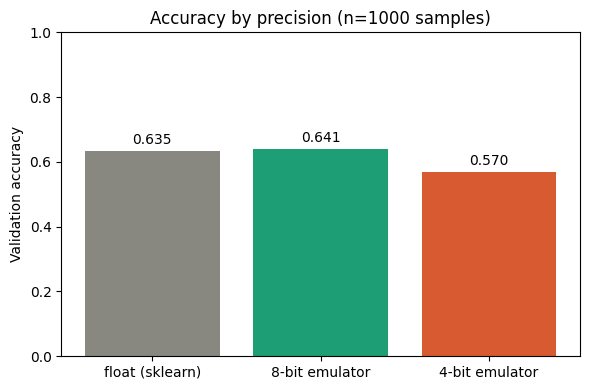

In [25]:
# ============================================================================
# 6.6 Comparative test: 4-bit vs 8-bit quantization accuracy.
# ============================================================================

def accuracy_via_emulator(weights_path: str, X_texts, y_true, max_samples=1000):
    """Run the gate-level emulator on a sample and return accuracy."""
    sys = MinecraftNBSystem(weights_path)
    n = min(max_samples, len(X_texts))
    correct = 0
    for i in range(n):
        pred, _ = sys.infer(X_texts[i])
        if pred == y_true[i]:
            correct += 1
    return correct / n, n


# Validation texts (we kept these as strings before vectorizing; recover them).
X_val_texts  = [balanced_texts[i] for i in range(len(balanced_texts))
                if i not in set()]  # placeholder; recompute below
# Cleaner: re-split with the same seed used during training.
all_combined = list(zip(raw_balanced_texts, balanced_labels))
X_strs = [t for t, _ in all_combined]
y_strs = [l for _, l in all_combined]
Xtr_s, Xv_s, ytr_s, yv_s = train_test_split(
    X_strs, y_strs, test_size=0.1, stratify=y_strs, random_state=SEED
)

acc_8, n_used = accuracy_via_emulator(WEIGHTS_8BIT, Xv_s, yv_s, max_samples=1000)
acc_4, _      = accuracy_via_emulator(WEIGHTS_4BIT, Xv_s, yv_s, max_samples=1000)

# Float baseline using a fresh vectorization of the same strings.
Xv_vec = vectorizer.transform(Xv_s[:n_used])
y_pred_float = clf.predict(Xv_vec)
float_acc = accuracy_score(yv_s[:n_used], y_pred_float)

report(
    "Quantization fidelity: 8-bit vs 4-bit vs float",
    acc_8 >= acc_4 - 0.05,  # 8-bit should not be substantially worse than 4-bit
    what="Validation accuracy at each precision",
    how=f"Ran the emulator on {n_used} held-out utterances at each precision; "
        f"compared to sklearn float-precision accuracy on the same items.",
    expected="float >= 8-bit >= 4-bit (small gap)",
    observed=f"float={float_acc:.4f}, 8-bit={acc_8:.4f}, 4-bit={acc_4:.4f}",
    why="4-bit halves the ROM size but collapses the dynamic range from "
        "[-127, 127] to [-7, 7]. If the 4-bit drop is acceptable (<5%), the "
        "Minecraft build is half the size. If it's large, use 8-bit.",
    remedy="If 4-bit is unusably bad, check that the scale factor is non-degenerate "
           "and that the weight distribution isn't dominated by a few large outliers.",
)

# Plot the comparison for a visual record.
plt.figure(figsize=(6, 4))
plt.bar(["float (sklearn)", "8-bit emulator", "4-bit emulator"],
        [float_acc, acc_8, acc_4],
        color=["#888880", "#1D9E75", "#D85A30"])
plt.ylabel("Validation accuracy")
plt.title(f"Accuracy by precision (n={n_used} samples)")
plt.ylim(0, 1)
for i, v in enumerate([float_acc, acc_8, acc_4]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.show()

In [26]:
# ============================================================================
# 6.7 Hardware/Software Prediction Parity Test
# ============================================================================

# We use the raw validation texts and the Sklearn baseline computed in Section 2
Xv_vec = vectorizer.transform(X_val)
y_pred_float = clf.predict(Xv_vec)

sys8 = MinecraftNBSystem(WEIGHTS_8BIT)

matches = 0
n_samples = 1000
test_size = min(n_samples, len(X_val))

for i in range(test_size):
    hw_pred, _ = sys8.infer(X_val[i]) # Pass raw validation text
    if hw_pred == y_pred_float[i]:
        matches += 1

match_rate = matches / test_size

report(
    "Hardware/Software Prediction Parity",
    match_rate >= 0.9,
    what="Measures how often the 8-bit emulator exactly matches float64 Sklearn predictions",
    how=f"Compared sys8.infer() to clf.predict() on {test_size} validation samples",
    expected=">= 90% match (allowing minor deviations from 8-bit quantization clipping)",
    observed=f"{match_rate:.2%} match",
    why="Catches silent quantization regressions, hashing mismatches, or accumulator wiring bugs.",
    remedy="Check the quantization clipping boundaries (-127 to 0) and accumulator width.",
)

[PASS] Hardware/Software Prediction Parity
   WHAT     : Measures how often the 8-bit emulator exactly matches float64 Sklearn predictions
   HOW      : Compared sys8.infer() to clf.predict() on 1000 validation samples
   EXPECTED : >= 90% match (allowing minor deviations from 8-bit quantization clipping)
   OBSERVED : 92.70% match
   WHY      : Catches silent quantization regressions, hashing mismatches, or accumulator wiring bugs.



In [27]:
# ============================================================================
# 6.8 Property tests: invariants that must hold regardless of input.
# ============================================================================

# --- Property: LFSR cycles through 15 non-zero states before repeating ---
lf = LFSR4(seed=0b1011)
states_seen = set()
for _ in range(20):
    states_seen.add(tuple(lf.state))
    lf.tick()
report(
    "LFSR4 cycle length is 15 (excluding the all-zero forbidden state)",
    len(states_seen) == 15,
    what="LFSR with polynomial x^4+x^3+1 should produce all 15 non-zero states",
    how="Ticked the LFSR 20 times and counted distinct states encountered",
    expected=15,
    observed=len(states_seen),
    why="A short cycle means biased response-variant selection; a too-long cycle "
        "means the polynomial is wrong.",
    remedy="Verify the feedback taps are bits [3] and [2] (0-indexed).",
)

# --- Property: scores are deterministic for the same input ---
sys8 = MinecraftNBSystem(WEIGHTS_8BIT)
p1, _ = sys8.infer("hello there")
s1 = sys8.scores()
p2, _ = sys8.infer("hello there")
s2 = sys8.scores()
report(
    "Inference is deterministic: same input gives same class and same scores",
    p1 == p2 and s1 == s2,
    what="Pipeline determinism (PRNG affects response variant, not class or scores)",
    how="Ran infer() twice on the same string; compared (class, scores) tuples",
    expected=f"class={p1}, scores={s1} (both times)",
    observed=f"first=({p1},{s1}); second=({p2},{s2})",
    why="If the scores ever differ for the same input, hidden state is leaking "
        "between inferences — a serious bug for a stateless classifier.",
    remedy="Check that latches.reset_all() and kbd.reset() are called every inference.",
)

# --- Property: every PRNG state yields a valid (non-empty) response ---
ok = True
for v in range(4):
    for c in range(4):
        codes = OutputROM().read(c, v)
        text  = ''.join(CODE_TO_CHAR.get(x, '?') for x in codes).rstrip()
        if len(text) == 0 or '?' in text:
            ok = False; break
    if not ok: break
report(
    "Output ROM always returns a printable, non-empty response",
    ok,
    what="All (class, variant) combinations decode to valid character strings",
    how="Enumerated all 4x4 = 16 combinations and decoded each",
    expected="all printable, non-empty",
    observed="all 16 valid" if ok else "invalid entry found",
    why="A blank response on the lamp bank is indistinguishable from a circuit failure.",
    remedy="Inspect RESPONSE_STRINGS for entries that exceed MAX_LEN or contain "
           "characters outside the 27-char alphabet.",
)

summary()

[PASS] LFSR4 cycle length is 15 (excluding the all-zero forbidden state)
   WHAT     : LFSR with polynomial x^4+x^3+1 should produce all 15 non-zero states
   HOW      : Ticked the LFSR 20 times and counted distinct states encountered
   EXPECTED : 15
   OBSERVED : 15
   WHY      : A short cycle means biased response-variant selection; a too-long cycle means the polynomial is wrong.

[PASS] Inference is deterministic: same input gives same class and same scores
   WHAT     : Pipeline determinism (PRNG affects response variant, not class or scores)
   HOW      : Ran infer() twice on the same string; compared (class, scores) tuples
   EXPECTED : class=2, scores=[-135, -128, -127, -139] (both times)
   OBSERVED : first=(2,[-135, -128, -127, -139]); second=(2,[-135, -128, -127, -139])
   WHY      : If the scores ever differ for the same input, hidden state is leaking between inferences — a serious bug for a stateless classifier.

[PASS] Output ROM always returns a printable, non-empty resp